13.	Perform DBSCAN algorithm for weather station clustering. Utilize proper data cleaning and feature selection. Also, plot all outlier of the cluster label.

Dataset: Weather Station dataset


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

In [ ]:
weather_df = pd.read_csv("weather-stations.csv")
weather_df.head()

,Stn_Name,Lat,Long,Prov,Tm,DwTm,D,Tx,DwTx,Tn,...,DwP,P%N,S_G,Pd,BS,DwBS,BS%,HDD,CDD,Stn_No
0,CHEMAINUS,48.935,-123.742,BC,8.2,0.0,NaN,13.5,0.0,1.0,...,0.0,NaN,0.0,12.0,NaN,NaN,NaN,273.3,0.0,1011500
1,COWICHAN LAKE FORESTRY,48.824,-124.133,BC,7.0,0.0,3.0,15.0,0.0,-3.0,...,0.0,104.0,0.0,12.0,NaN,NaN,NaN,307.0,0.0,1012040
2,LAKE COWICHAN,48.829,-124.052,BC,6.8,13.0,2.8,16.0,9.0,-2.5,...,9.0,NaN,NaN,11.0,NaN,NaN,NaN,168.1,0.0,1012055
3,DISCOVERY ISLAND,48.425,-123.226,BC,NaN,NaN,NaN,12.5,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1012475
4,DUNCAN KELVIN CREEK,48.735,-123.728,BC,7.7,2.0,3.4,14.5,2.0,-1.0,...,2.0,NaN,NaN,11.0,NaN,NaN,NaN,267.7,0.0,1012573


In [ ]:
features = ['Lat', 'Long', 'Tm', 'Tx', 'Tn', 'P', 'HDD', 'CDD']
weather_selected = weather_df[features].dropna()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(weather_selected)

In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

In [ ]:
weather_selected['Cluster'] = labels

In [ ]:
plt.figure(figsize=(10, 6))
outliers = weather_selected[weather_selected['Cluster'] == -1]
clusters = weather_selected[weather_selected['Cluster'] != -1]


<Figure size 1000x600 with 0 Axes>

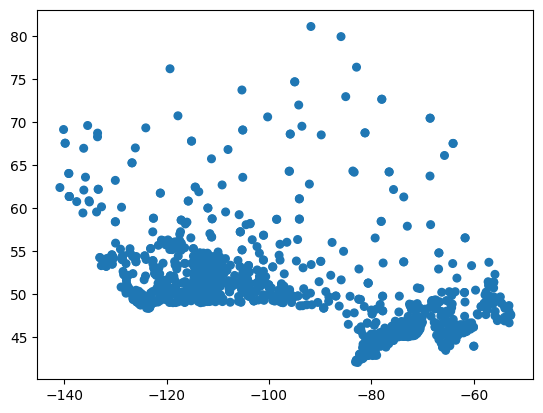

In [ ]:
plt.scatter(clusters['Long'], clusters['Lat'], c=clusters['Cluster'], cmap='tab10', s=30, label='Clustered')

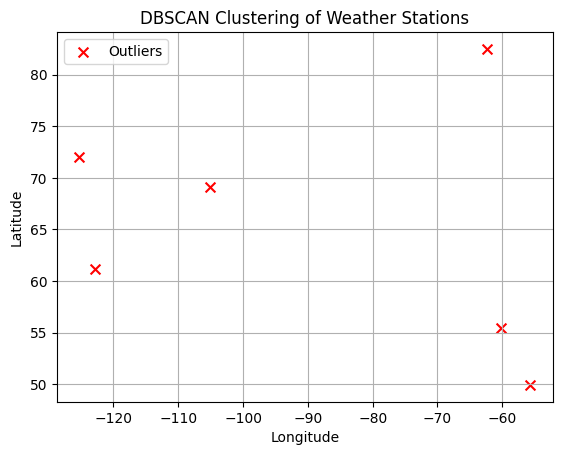

In [ ]:
plt.scatter(outliers['Long'], outliers['Lat'], c='red', marker='x', s=50, label='Outliers')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Clustering of Weather Stations")
plt.legend()
plt.grid(True)
plt.show()